# Credit Risk Portfolio Dashboard

In [1]:
## 1. Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

In [2]:
## 2. Simulate Sample Loan Portfolio
# Set random seed for reproducibility
np.random.seed(42)

# Number of borrowers
num_borrowers = 1000

# Define ranges for borrower features
income_min = 20000
income_max = 120000

loan_min = 5000
loan_max = 50000

age_min = 21
age_max = 65

credit_score_min = 300
credit_score_max = 900

portfolio = pd.DataFrame({
    'income': np.random.randint(income_min, income_max, num_borrowers),
    'loan_amount': np.random.randint(loan_min, loan_max, num_borrowers),
    'credit_score': np.random.randint(credit_score_min, credit_score_max, num_borrowers),
    'age': np.random.randint(age_min, age_max, num_borrowers),
})

# Default simulation
portfolio['loan_to_income'] = portfolio['loan_amount'] / portfolio['income']
cs_probability = 0.05 + 0.4 * portfolio['loan_to_income'] + 0.0005 * (700 - portfolio['credit_score'])
cs_probability = np.clip(cs_probability, 0, 1)
portfolio['default'] = np.random.binomial(1, p=cs_probability, size=num_borrowers)
portfolio['default'] = portfolio['default'].clip(0,1)

In [3]:
## 3. Train-Test Split
X = portfolio[['income', 'loan_amount', 'credit_score', 'age']]
y = portfolio['default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
## 4. Logistic Regression Model for PD
model = LogisticRegression()
model.fit(X_train, y_train)

E:\Softwares\Installation Files\Python_313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [5]:
## 5. Predict Probability of Default (PD)
portfolio['PD'] = model.predict_proba(X)[:,1]

In [6]:
## 6. Define LGD and EAD
LGD = 0.6
portfolio['LGD'] = LGD
portfolio['EAD'] = portfolio['loan_amount']

In [7]:
## 7. Calculate Expected Loss (EL)
portfolio['Expected_Loss'] = portfolio['PD'] * portfolio['LGD'] * portfolio['EAD']

In [8]:
## 8. Portfolio-level Metrics
total_expected_loss = portfolio['Expected_Loss'].sum()
average_PD = portfolio['PD'].mean()
average_EL = portfolio['Expected_Loss'].mean()

print(f"Total Expected Loss for Portfolio: ₹{total_expected_loss:,.2f}")
print(f"Average Probability of Default (PD): {average_PD:.4f}")
print(f"Average Expected Loss per Loan: ₹{average_EL:,.2f}")

Total Expected Loss for Portfolio: ₹5,373,879.21
Average Probability of Default (PD): 0.2730
Average Expected Loss per Loan: ₹5,373.88


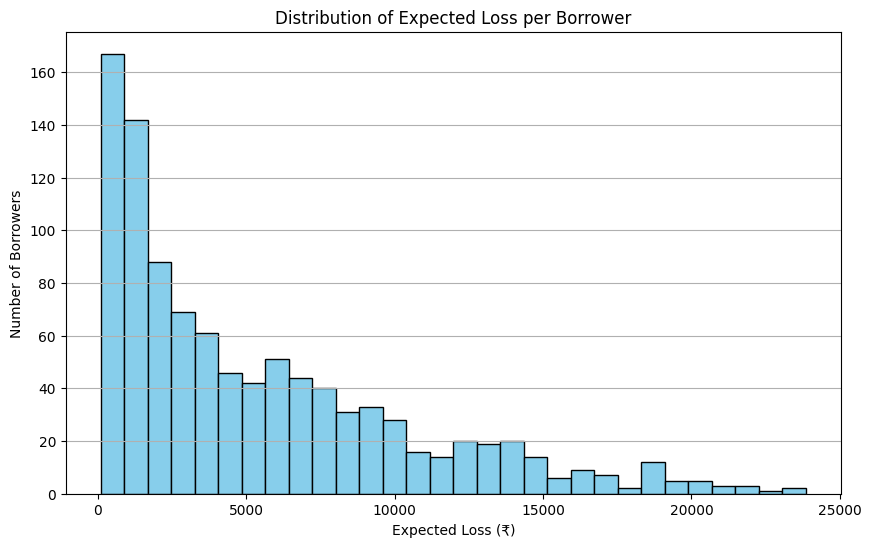

In [9]:
## 9. Visualize Expected Loss Distribution
plt.figure(figsize=(10,6))
plt.hist(portfolio['Expected_Loss'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Expected Loss per Borrower')
plt.xlabel('Expected Loss (₹)')
plt.ylabel('Number of Borrowers')
plt.grid(axis='y')
plt.show()

In [10]:
## 10. Preview Few Rows of Portfolio
print("\nSample of portfolio data:")
portfolio.head()


Sample of portfolio data:


,income,loan_amount,credit_score,age,loan_to_income,default,PD,LGD,EAD,Expected_Loss
0,35795,39529,503,46,1.104316,1,0.580832,0.6,39529,13775.827109
1,20860,15167,464,47,0.727085,0,0.363637,0.6,15167,3309.166059
2,96820,15554,604,28,0.160649,0,0.093591,0.6,15554,873.428375
3,74886,22260,796,39,0.297252,1,0.122674,0.6,22260,1638.432086
4,26265,8812,855,62,0.335504,0,0.130721,0.6,8812,691.146732
